# 🏥 Medical Insurance Cost Prediction

**Goal:** Predict how much a person will be charged for medical insurance, using details such as age, BMI, smoking status and region.

**Type of problem:** Regression (we predict a *number*, not a category).

**Steps in this notebook**
1. Import libraries
2. Load the data
3. Inspect the data
4. Clean the data
5. Explore the data (visualizations)
6. Prepare the data for machine learning
7. Build a baseline model
8. Test an idea that does not help (`bmi_smoker`)
9. Better features for the linear model
10. Try a smarter model (Gradient Boosting)
11. Compare all models
12. Check the errors (residuals)
14. Summary

## 1. Import Libraries
Libraries are ready-made toolboxes so we don't have to write everything from scratch.

In [44]:
import numpy as np                 # numbers and maths
import pandas as pd                # tables (DataFrames)
import matplotlib.pyplot as plt    # drawing charts
import seaborn as sns              # prettier charts

from sklearn.model_selection import train_test_split, cross_val_score, KFold   # splitting and cross-validation
from sklearn.linear_model import LinearRegression             # simple straight-line model
from sklearn.ensemble import GradientBoostingRegressor        # smarter tree-based model
from sklearn.compose import TransformedTargetRegressor        # train on log(charges), score in dollars
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # scoring tools

sns.set_theme(style="whitegrid")   # one clean chart style for the whole notebook

## 2. Load the Data
We read the CSV file into a table called `df` and look at the first 5 rows.

| Column | Meaning |
|---|---|
| `age` | Age of the person |
| `sex` | male / female |
| `bmi` | Body Mass Index (weight vs. height; 30+ is considered obese) |
| `children` | Number of children covered by the insurance |
| `smoker` | yes / no |
| `region` | Area of the US where the person lives |
| `charges` | 🎯 **Target** – the medical cost we want to predict |

In [45]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 3. Inspect the Data
Before doing anything else, we check the size, data types, basic statistics and any problems.

In [46]:
print("Rows, Columns:", df.shape)
print()
df.info()   # column names, data types and number of non-empty values

Rows, Columns: (1338, 7)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [47]:
# Basic statistics (average, min, max ...) for the number columns
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [48]:
# Are there any missing values?  (0 everywhere = good)
print("Missing values per column:")
print(df.isnull().sum())

# Are there any duplicate rows?
print("\nNumber of duplicate rows:", df.duplicated().sum())
df[df.duplicated(keep=False)]   # show the duplicated rows

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Number of duplicate rows: 1


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


## 4. Clean the Data
The data has no missing values, but it has one repeated row. Repeated rows can make the model "see" the same person twice, so we remove them.

In [49]:
df = df.drop_duplicates(keep="first")
print("Duplicate rows left:", df.duplicated().sum())
print("Rows, Columns:", df.shape)

Duplicate rows left: 0
Rows, Columns: (1337, 7)


## 5. Explore the Data (EDA)
EDA = *Exploratory Data Analysis*. We draw charts to understand what affects the insurance charges.

### 5.1 How are the charges distributed?
The **left** chart shows the real charges: most people pay a little, a few pay a lot (a long tail on the right).
Models work better when the target is more "bell-shaped", so on the **right** we also show the **logarithm** of the charges, which is much more balanced.

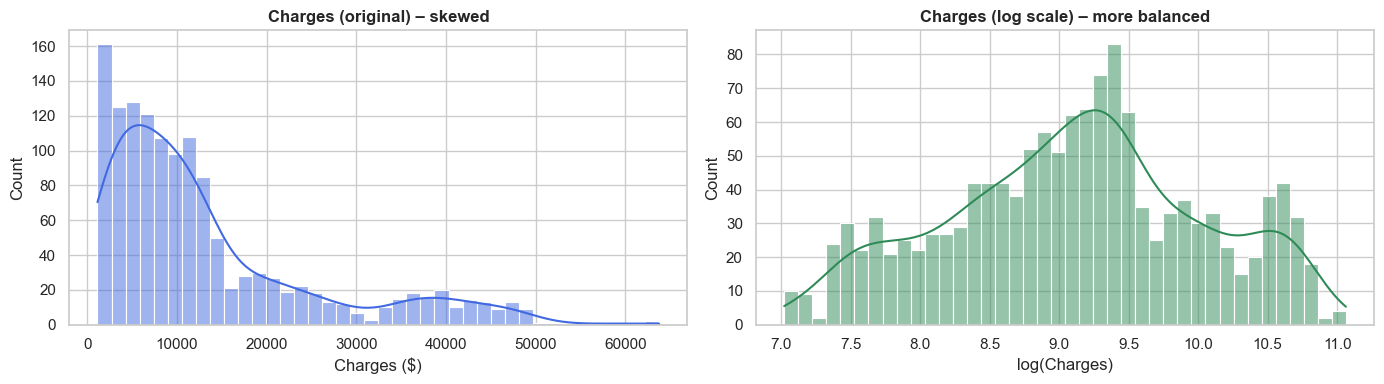

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["charges"], kde=True, bins=40, color="royalblue", ax=axes[0])
axes[0].set_title("Charges (original) – skewed", weight="bold")
axes[0].set_xlabel("Charges ($)")

sns.histplot(np.log(df["charges"]), kde=True, bins=40, color="seagreen", ax=axes[1])
axes[1].set_title("Charges (log scale) – more balanced", weight="bold")
axes[1].set_xlabel("log(Charges)")

plt.tight_layout()
plt.show()

### 5.2 Do smokers pay more?

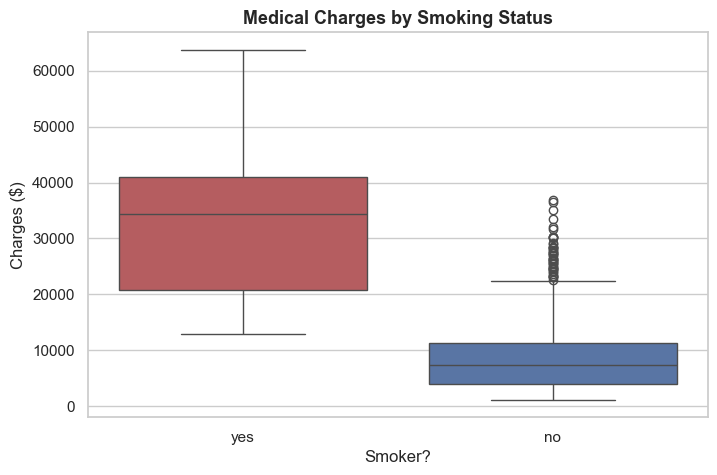

In [51]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="smoker", y="charges", hue="smoker",
            palette={"no": "#4C72B0", "yes": "#C44E52"}, legend=False)
plt.title("Medical Charges by Smoking Status", fontsize=13, weight="bold")
plt.xlabel("Smoker?")
plt.ylabel("Charges ($)")
plt.show()

**What we see:** Smokers are charged far more than non-smokers. Smoking looks like the most important factor.

### 5.3 How do age and BMI affect charges?

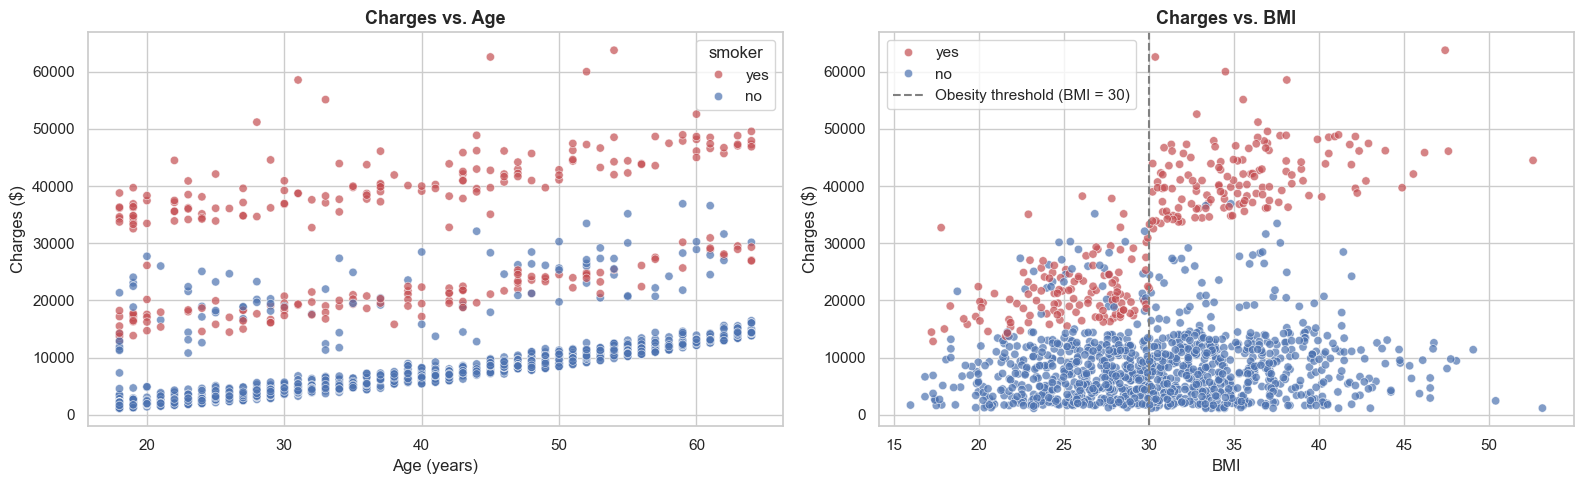

In [52]:
palette = {"no": "#4C72B0", "yes": "#C44E52"}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Age vs Charges
sns.scatterplot(data=df, x="age", y="charges", hue="smoker",
                palette=palette, alpha=0.7, ax=axes[0])
axes[0].set_title("Charges vs. Age", fontsize=13, weight="bold")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Charges ($)")

# Right: BMI vs Charges (dashed line marks the obesity threshold, BMI = 30)
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker",
                palette=palette, alpha=0.7, ax=axes[1])
axes[1].axvline(x=30, color="gray", linestyle="--", label="Obesity threshold (BMI = 30)")
axes[1].set_title("Charges vs. BMI", fontsize=13, weight="bold")
axes[1].set_xlabel("BMI")
axes[1].set_ylabel("Charges ($)")
axes[1].legend()

plt.tight_layout()
plt.show()

**What we see:**
- Charges go up with age, and smokers form their own higher band.
- For **non-smokers**, BMI barely changes the charges. For **smokers with BMI above 30**, charges jump sharply.
  This means *BMI and smoking work together* – we will use this idea in Step 8.

## 6. Prepare the Data for Machine Learning

### 6.1 Convert text columns into numbers
Models only understand numbers, so we turn text columns (`sex`, `smoker`, `region`) into 0/1 columns.
This is called **one-hot encoding**. `drop_first=True` removes one redundant column per feature.
Example: `sex_male = 1` means male, `sex_male = 0` means female.

In [53]:
df_encoded = pd.get_dummies(df, columns=["sex", "smoker", "region"], drop_first=True, dtype=int)
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


### 6.2 Choose features (X) and target (y)
- **X (features)** = the information we give the model (age, bmi, smoker ...)
- **y (target)** = the answer we want it to predict (`charges`)

We predict the **log of charges** (see 5.1) because it trains better. Later we convert predictions back to dollars.

> ⚠️ **Important:** `charges` must NOT be inside `X`. If it is, the model can "cheat" by looking at the answer, and the scores become fake.

In [54]:
X = df_encoded.drop(columns=["charges"])     # features only – the answer is removed
y_dollars = df_encoded["charges"]            # real charges in dollars
y_log = np.log(y_dollars)                    # charges on log scale (what the model learns)

print("Features used:", list(X.columns))

Features used: ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


### 6.3 Split into training and testing data
- **Training set (80%)** – the model learns from this.
- **Testing set (20%)** – hidden during learning; used to check how well the model works on *new* people.

`random_state=42` makes the split the same every time, so results can be repeated.

In [55]:
X_train, X_test, y_train_log, y_test_log, y_train_usd, y_test_usd = train_test_split(
    X, y_log, y_dollars, test_size=0.2, random_state=42
)
print("Training rows:", len(X_train), "| Testing rows:", len(X_test))

Training rows: 1069 | Testing rows: 268


## 7. Baseline Model (Linear Regression)
Linear Regression finds a straight-line formula: *charges depend on age, bmi, smoker, ...*
We call this the **baseline** – the simple first model that we try to beat later.

### A helper function to score models
We will score more than one model, so we write the scoring steps once and reuse them.
It reports the scores in **dollars** (the real-world result) and also the R² on the log scale (what the model actually trained on).

| Metric | Meaning | Better is… |
|---|---|---|
| **R²** | How much of the variation the model explains (1.0 = perfect, 0 = no better than guessing the average) | higher |
| **MAE** | Average mistake in dollars | lower |
| **RMSE** | Like MAE but punishes big mistakes more | lower |

In [56]:
results = []   # every model's scores are collected here for the final comparison

def evaluate(model, X_test, y_test_log, y_test_usd, name="Model"):
    """Predict on the test set and print the scores (in log scale AND in real dollars)."""
    pred_log = model.predict(X_test)      # prediction on log scale
    pred_usd = np.exp(pred_log)           # undo the log -> real dollars
    r2_log = r2_score(y_test_log, pred_log)

    r2   = r2_score(y_test_usd, pred_usd)
    mae  = mean_absolute_error(y_test_usd, pred_usd)
    rmse = np.sqrt(mean_squared_error(y_test_usd, pred_usd))

    results.append({"Model": name, "R2 (dollars)": round(r2, 4), "MAE ($)": round(mae), "RMSE ($)": round(rmse)})
    print(f"{name}")
    print(f"  R2 (log scale) : {r2_log:.4f}")
    print(f"  R2 (dollars)   : {r2:.4f}   <- the score that matters")
    print(f"  MAE  (dollars) : ${mae:,.2f}")
    print(f"  RMSE (dollars) : ${rmse:,.2f}")
    return pred_log

In [57]:
# Train the baseline model
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train_log)

# Score it on the unseen test data
pred_log_base = evaluate(baseline_model, X_test, y_test_log, y_test_usd, name="Linear baseline")

Linear baseline
  R2 (log scale) : 0.8295
  R2 (dollars)   : 0.7180   <- the score that matters
  MAE  (dollars) : $3,756.21
  RMSE (dollars) : $7,197.97


## 8. Try to Improve the Model (Feature Engineering)
**Feature engineering** = creating a new, smarter column from existing ones.

In Step 5.3 we saw that BMI matters mostly for **smokers**. A straight-line model cannot see this by itself,
so we test an idea: add a new column

`bmi_smoker = bmi × smoker_yes`

For non-smokers this is 0 (no effect); for smokers it equals their BMI.
This is an **experiment** – we keep the change only if the score in dollars gets better.

In [58]:
# Add the new column to copies of the train and test features
X_train_eng = X_train.copy()
X_test_eng  = X_test.copy()
X_train_eng["bmi_smoker"] = X_train_eng["bmi"] * X_train_eng["smoker_yes"]
X_test_eng["bmi_smoker"]  = X_test_eng["bmi"]  * X_test_eng["smoker_yes"]

# Train the improved model (same split, so the comparison is fair)
improved_model = LinearRegression()
improved_model.fit(X_train_eng, y_train_log)

pred_log_imp = evaluate(improved_model, X_test_eng, y_test_log, y_test_usd, name="Linear + bmi_smoker (experiment)")

Linear + bmi_smoker (experiment)
  R2 (log scale) : 0.8370
  R2 (dollars)   : 0.5881   <- the score that matters
  MAE  (dollars) : $4,188.06
  RMSE (dollars) : $8,700.28


**Result:** The new column gives a tiny gain on the log scale, but the score in **dollars gets worse**
(R² drops and the average error grows). So this particular feature does **not** help, and we drop it.
A single straight multiplication is too crude: the real jump happens only when a smoker crosses BMI 30 (see the chart in 5.3).

## 9. Better Features for the Linear Model
Step 5.3 showed the real pattern: costs jump when a **smoker** has **BMI ≥ 30**, and smokers' costs also grow faster with **age**.
So we create two columns that describe exactly that:

- `obese_smoker` = 1 if the person is a smoker **and** has BMI ≥ 30, otherwise 0
- `age_smoker` = age × smoker_yes (age only counts for smokers)

In [59]:
def add_smart_features(data):
    """Return a copy of the table with the two new columns added."""
    data = data.copy()
    data["obese_smoker"] = ((data["bmi"] >= 30) & (data["smoker_yes"] == 1)).astype(int)
    data["age_smoker"]   = data["age"] * data["smoker_yes"]
    return data

X_train_fe = add_smart_features(X_train)
X_test_fe  = add_smart_features(X_test)

linear_fe = LinearRegression()
linear_fe.fit(X_train_fe, y_train_log)
pred_log_fe = evaluate(linear_fe, X_test_fe, y_test_log, y_test_usd, name="Linear + smart features")

Linear + smart features
  R2 (log scale) : 0.8771
  R2 (dollars)   : 0.8794   <- the score that matters
  MAE  (dollars) : $2,452.64
  RMSE (dollars) : $4,707.72


**Result:** A big jump! R² in dollars rises from about 0.72 to about 0.88 and the average error drops by over $1,000.
The lesson: *understanding the data (Step 5) beats guessing.*

## 10. Try a Smarter Model (Gradient Boosting)
Linear Regression can only draw straight lines. **Gradient Boosting** builds many small decision trees,
each one fixing the mistakes of the previous ones. It finds patterns like "smoker + high BMI" **by itself**, so we don't need to create special columns.

In [60]:
boost_model = GradientBoostingRegressor(
    n_estimators=150,     # number of small trees
    max_depth=3,          # how complex each tree may be
    learning_rate=0.05,   # how big each correction step is
    random_state=42,
)
boost_model.fit(X_train, y_train_log)
pred_log_boost = evaluate(boost_model, X_test, y_test_log, y_test_usd, name="Gradient Boosting")

Gradient Boosting
  R2 (log scale) : 0.8840
  R2 (dollars)   : 0.9007   <- the score that matters
  MAE  (dollars) : $2,040.44
  RMSE (dollars) : $4,272.10


## 11. Compare All Models

In [61]:
comparison = pd.DataFrame(results).sort_values("R2 (dollars)", ascending=False).reset_index(drop=True)
comparison

,Model,R2 (dollars),MAE ($),RMSE ($)
0,Gradient Boosting,0.9007,2040,4272
1,Linear + smart features,0.8794,2453,4708
2,Linear baseline,0.7180,3756,7198
3,Linear + bmi_smoker (experiment),0.5881,4188,8700


### Double-check with cross-validation
One train/test split can be lucky or unlucky. **Cross-validation** repeats the test 5 times on different parts of the data
and averages the result, which is a fairer score. (The scores are usually a bit lower than the single split – that is normal and more honest.)

In [62]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# TransformedTargetRegressor = "train on log(charges), but report results in dollars"
def log_wrapped(model):
    return TransformedTargetRegressor(regressor=model, func=np.log, inverse_func=np.exp)

X_all_fe = add_smart_features(X)   # all rows, with the smart features

cv_scores = {
    "Linear baseline":         cross_val_score(log_wrapped(LinearRegression()), X, y_dollars, cv=kfold, scoring="r2").mean(),
    "Linear + smart features": cross_val_score(log_wrapped(LinearRegression()), X_all_fe, y_dollars, cv=kfold, scoring="r2").mean(),
    "Gradient Boosting":       cross_val_score(log_wrapped(GradientBoostingRegressor(n_estimators=150, max_depth=3, learning_rate=0.05, random_state=42)),
                                               X, y_dollars, cv=kfold, scoring="r2").mean(),
}
for model_name, score in cv_scores.items():
    print(f"{model_name:25s} average R2 (5-fold, dollars): {score:.4f}")

Linear baseline           average R2 (5-fold, dollars): 0.4897
Linear + smart features   average R2 (5-fold, dollars): 0.8236
Gradient Boosting         average R2 (5-fold, dollars): 0.8539


## 12. Check the Errors (Residuals)
A **residual** = actual value − predicted value. A good model has residuals that:
- are scattered randomly around 0 (left chart), and
- form a bell shape centred at 0 (right chart).

We check the **Gradient Boosting model** (our best one). The charts use the **log scale**, because that is the scale the model learned on.

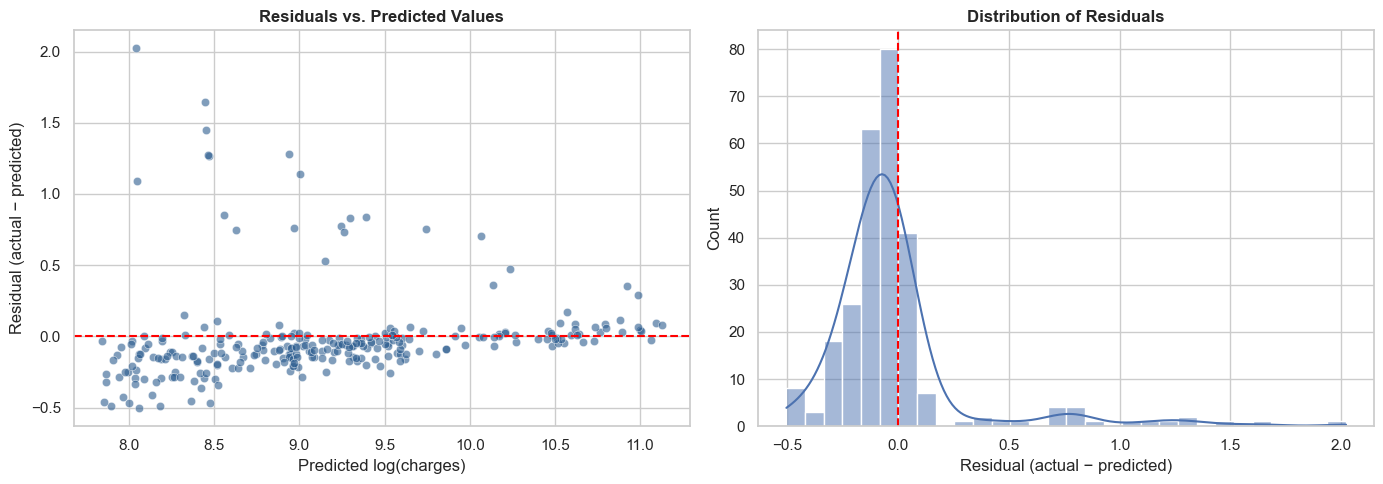

In [63]:
residuals = y_test_log - pred_log_boost

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: residuals vs predictions
sns.scatterplot(x=pred_log_base, y=residuals, alpha=0.6, color="#2b5c8f", ax=axes[0])
axes[0].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[0].set_title("Residuals vs. Predicted Values", fontsize=12, weight="bold")
axes[0].set_xlabel("Predicted log(charges)")
axes[0].set_ylabel("Residual (actual − predicted)")

# Right: distribution of residuals
sns.histplot(residuals, kde=True, bins=30, color="#4C72B0", ax=axes[1])
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("Distribution of Residuals", fontsize=12, weight="bold")
axes[1].set_xlabel("Residual (actual − predicted)")

plt.tight_layout()
plt.show()

**What we see:** Most residuals are tightly packed around 0, which is good. A small group of people has residuals well above 0
(the model **under-predicted** their cost). These are probably unusual cases, such as non-smokers with very high bills,
that no feature in this dataset can explain. This is the main reason the model is not perfect.

## 13. Make Predictions on New People
Now we use the trained model like a real insurance company would: give it **new people it has never seen** and ask what they would be charged.

### 13.1 Sample data
Each row is one made-up person. The columns are the same as the original data, **without** `charges` (that is what we want to predict).
The people are chosen on purpose to cover different situations.

In [64]:
new_people = pd.DataFrame({
    "age":      [19,       30,       45,       45,       23,       55,       60,       35],
    "sex":      ["female", "male",   "female", "male",   "male",   "female", "male",   "female"],
    "bmi":      [22.0,     26.5,     28.0,     36.0,     24.0,     33.5,     31.0,     41.0],
    "children": [0,        2,        1,        3,        0,        0,        2,        1],
    "smoker":   ["no",     "no",     "no",     "yes",    "yes",    "yes",    "no",     "no"],
    "region":   ["southwest", "northwest", "southeast", "northeast", "southeast", "southwest", "northeast", "northwest"],
})

# A short note about why each person was chosen (only for us to read, not used by the model)
notes = [
    "Young, healthy non-smoker",
    "Adult non-smoker, normal weight",
    "Middle-aged non-smoker, 1 child",
    "Middle-aged OBESE SMOKER (highest risk group)",
    "Young smoker, normal weight",
    "Older obese smoker",
    "Older non-smoker, obese",
    "Non-smoker with very high BMI",
]
new_people

,age,sex,bmi,children,smoker,region
0,19,female,22.0,0,no,southwest
1,30,male,26.5,2,no,northwest
2,45,female,28.0,1,no,southeast
3,45,male,36.0,3,yes,northeast
4,23,male,24.0,0,yes,southeast
5,55,female,33.5,0,yes,southwest
6,60,male,31.0,2,no,northeast
7,35,female,41.0,1,no,northwest


### 13.2 Prepare the new data exactly like the training data
The model expects the **same columns in the same order** as during training, so we repeat the encoding step by hand
(text to 0/1). If this step does not match the training data, the predictions will be wrong.

In [65]:
def prepare_new_data(people):
    """Turn raw customer details into the numeric table the model was trained on."""
    data = pd.DataFrame({
        "age":              people["age"],
        "bmi":              people["bmi"],
        "children":         people["children"],
        "sex_male":         (people["sex"] == "male").astype(int),
        "smoker_yes":       (people["smoker"] == "yes").astype(int),
        "region_northwest": (people["region"] == "northwest").astype(int),
        "region_southeast": (people["region"] == "southeast").astype(int),
        "region_southwest": (people["region"] == "southwest").astype(int),
    })
    return data[X.columns]    # same column order as training

new_X = prepare_new_data(new_people)
new_X

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,22.0,0,0,0,0,0,1
1,30,26.5,2,1,0,1,0,0
2,45,28.0,1,0,0,0,1,0
3,45,36.0,3,1,1,0,0,0
4,23,24.0,0,1,1,0,1,0
5,55,33.5,0,0,1,0,0,1
6,60,31.0,2,1,0,0,0,0
7,35,41.0,1,0,0,1,0,0


### 13.3 Predict the charges
The model predicts on the **log scale**, so we convert back to dollars with `np.exp`.
We use our best model (Gradient Boosting) and also show the simple linear baseline for comparison.

In [66]:
predictions = new_people.copy()
predictions["Who"] = notes
predictions["Predicted charges – Gradient Boosting ($)"] = np.exp(boost_model.predict(new_X)).round(0)
predictions["Predicted charges – Linear baseline ($)"]   = np.exp(baseline_model.predict(new_X)).round(0)

predictions[["Who", "age", "bmi", "smoker", "Predicted charges – Gradient Boosting ($)", "Predicted charges – Linear baseline ($)"]]

,Who,age,bmi,smoker,Predicted charges – Gradient Boosting ($),Predicted charges – Linear baseline ($)
0,"Young, healthy non-smoker",19,22.0,no,1938.0,2660.0
1,"Adult non-smoker, normal weight",30,26.5,no,5791.0,4906.0
2,"Middle-aged non-smoker, 1 child",45,28.0,no,8674.0,7485.0
3,Middle-aged OBESE SMOKER (highest risk group),45,36.0,yes,43211.0,49686.0
4,"Young smoker, normal weight",23,24.0,yes,16949.0,13117.0
5,Older obese smoker,55,33.5,yes,41965.0,48953.0
6,"Older non-smoker, obese",60,31.0,no,14968.0,15078.0
7,Non-smoker with very high BMI,35,41.0,no,6152.0,6881.0


**How to read this:** Non-smokers get low predictions, smokers get much higher ones, and the **obese smokers** are the most expensive – exactly what we saw in the charts.
Notice that the two models disagree most for smokers: the linear baseline over-predicts the obese smokers and under-predicts smokers with a normal BMI, because a straight line cannot capture the jump at BMI 30, while Gradient Boosting can.
These are estimates with an average error of about $2,000, not exact prices.

## 14. Summary
### What we did
1. Loaded and inspected 1,338 insurance records and removed 1 duplicate row.
2. Found that **smoking** is the biggest driver of cost, followed by **age**, and that **BMI** matters mostly for smokers.
3. Converted text columns to numbers and predicted the **log of charges**, then converted predictions back to dollars.
4. Built four models and compared them fairly on unseen data.

### Results (tested on unseen data, in dollars)
| Model | R² | Average error (MAE) |
|---|---|---|
| Linear baseline | 0.72 | about $3,756 |
| Linear + `bmi_smoker` (did not help) | 0.59 | about $4,188 |
| Linear + smart features (`obese_smoker`, `age_smoker`) | 0.88 | about $2,453 |
| **Gradient Boosting (best)** | **0.90** | **about $2,040** |

With 5-fold cross-validation the scores are a little lower (Linear baseline 0.49, Linear + smart features 0.82, Gradient Boosting 0.85),
but the ranking stays the same. So the improvement is real.

### Key lessons
- **Never leave the target column inside X.** Otherwise the model "cheats" and gives fake scores.
- **Judge the model in the real unit (dollars)**, not only on the log scale.
- **A feature idea is only useful if it improves the test score.** `bmi_smoker` did not; features based on what the charts showed did.
- Charts (EDA) tell you which features to build. A smarter model can find the same patterns automatically.

### Ideas to try next
- Tune the Gradient Boosting settings (`n_estimators`, `max_depth`, `learning_rate`) with `GridSearchCV`.
- Try Random Forest or XGBoost.
- Save the best model with `joblib` so it can be reused in an app.

## 15. Save the Best Model for Deployment

We package the top-performing **Gradient Boosting** model together with the column feature names, performance metrics, and baseline reference values into `insurance_cost_model.joblib` for use in our interactive web application.

In [ ]:
import joblib
import os

# Bundle model with necessary metadata for web app deployment
model_bundle = {
    "model": boost_model,
    "baseline_model": baseline_model,
    "feature_names": list(X.columns),
    "metrics": {
        "r2": float(r2_score(y_test_usd, np.exp(boost_model.predict(X_test)))),
        "mae": float(mean_absolute_error(y_test_usd, np.exp(boost_model.predict(X_test)))),
    },
    "stats": {
        "mean_charges": float(df["charges"].mean()),
        "median_charges": float(df["charges"].median()),
        "smoker_mean": float(df[df["smoker"] == "yes"]["charges"].mean()),
        "non_smoker_mean": float(df[df["smoker"] == "no"]["charges"].mean()),
    }
}

output_file = "insurance_cost_model.joblib"
joblib.dump(model_bundle, output_file)
print(f"[SUCCESS] Saved trained model bundle to: {output_file}")
print(f"File size: {os.path.getsize(output_file) / 1024:.2f} KB")
